# Lab 02: Development Environment and the Basics of Distributed Processing

Before we can trust the processing and forecasting of large volumes of observations,
we first need a **reproducible environment in which anyone, at any time, gets the
same result**.

We inspect the runtime environment with code, confirm
reproducibility with numbers, and then see how shell pipes and Git are the archetypes
of data processing and experiment reproduction. In the second half, we build small,
runnable simulations of the **core ideas of distributed processing (block splitting,
replication, MapReduce)** that Spark will later scale up.



## Learning Objectives

By the end of this lab you will be able to:

- Inspect the runtime environment (Python, packages, CPU) **with code** and produce a
  reusable **environment checklist** (this week's deliverable).
- Confirm with numbers why **seed pinning and version pinning** plus a
  `requirements.txt` are the heart of reproducibility.
- Understand **shell pipes** (`cat | cut | sort | uniq -c`) and **Git version
  control** as the archetypes of data processing and experiment reproduction.
- Simulate **HDFS** block splitting and replication (fault tolerance), and verify
  that $r$ replicas survive the simultaneous failure of $r-1$ nodes.
- Implement distributed aggregation with **MapReduce** (map → shuffle → reduce) and
  confirm that the result matches the serial answer regardless of the number of
  partitions.
- Explain why distributed and parallel tools are needed in terms of **data volume**,
  and see how this connects to Spark in Week 3.


In [12]:

import sys, os, platform, subprocess, tempfile, shutil
import importlib.util
import math
from collections import Counter

import numpy as np
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
rng = np.random.default_rng(0)   # fixed seed for reproducibility

# Today's shell/Git demos happen only inside this temporary working directory
# (the course repository is never touched).
WORK = tempfile.mkdtemp(prefix="course410_wk02_")
print("numpy", np.__version__)
print("working directory:", WORK)


numpy 2.3.3
working directory: /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk02_1ub3df0c


---
## 1. Self-inspecting the runtime environment

The first step towards reproducible work is knowing **"exactly which environment am I
running in right now?"** The Python version, the interpreter path, the CPU core
count, and so on.

Start with the interpreter and the hardware. The CPU core count connects directly to
Spark's `local[*]` later on, and to the parallel processing of Weeks 10–11.


In [13]:

print("Python version :", sys.version.split()[0])
print("interpreter    :", sys.executable)
print("platform       :", platform.platform())
print("machine        :", platform.machine())
print("CPU cores      :", os.cpu_count(), " -> later the ceiling on Spark local[*], OpenMP/MPI parallelism")


Python version : 3.11.0
interpreter    : /Users/pepc/Teaching/410/.venv/bin/python
platform       : macOS-15.7.3-arm64-arm-64bit
machine        : arm64
CPU cores      : 11  -> later the ceiling on Spark local[*], OpenMP/MPI parallelism


Beyond Python packages, this course depends on a few **external shell tools**: `git`
for version control, `gcc-14` for Week 10's OpenMP (Homebrew gcc, not Apple clang),
and `mpicc`/`mpirun` for Week 11's MPI. `shutil.which` checks whether the executables
are on `PATH` — it is fine if some are missing now, as long as you install them before
the relevant week.


In [14]:

TOOLS = [
    ("git",     "version control",       "today / all weeks"),
    ("python3", "interpreter",           "all weeks"),
    ("gcc-14",  "OpenMP build (-fopenmp)", "week 10"),
    ("mpicc",   "MPI compiler",          "week 11"),
    ("mpirun",  "MPI launcher",          "week 11"),
    ("java",    "Spark (JVM) runtime",   "weeks 3-4"),
]
print(f"{'Tool':<10}{'Status':<9}{'Path':<40}{'Needed for'}")
print("-" * 78)
for tool, use, wk in TOOLS:
    path = shutil.which(tool)
    mark = "found" if path else "missing"
    print(f"{tool:<10}{mark:<9}{(path or '-'):<40}{wk}")
print("-" * 78)


Tool      Status   Path                                    Needed for
------------------------------------------------------------------------------
git       found    /usr/bin/git                            today / all weeks
python3   found    /Users/pepc/Teaching/410/.venv/bin/python3all weeks
gcc-14    found    /opt/homebrew/bin/gcc-14                week 10
mpicc     found    /opt/homebrew/bin/mpicc                 week 11
mpirun    found    /opt/homebrew/bin/mpirun                week 11
java      found    /opt/homebrew/opt/openjdk@21/bin/java   weeks 3-4
------------------------------------------------------------------------------


Now check the packages this course uses week by week. `importlib.util.find_spec`
reports whether a module is installed **without importing it**, so the cell survives
even if some package is not there yet. For the installed ones we also read the version
and lay everything out as a table.


In [15]:

REQUIRED = [
    ("numpy",         "numeric arrays",      "all weeks"),
    ("pandas",        "tabular data",        "3+"),
    ("matplotlib",    "plotting",            "all weeks"),
    ("nbformat",      "notebook build",      "environment"),
    ("nbclient",      "notebook execution",  "environment"),
    ("xarray",        "labelled ND arrays",  "6-9"),
    ("dask",          "lazy/parallel ops",   "7"),
    ("netCDF4",       "NetCDF I/O",          "6"),
    ("geopandas",     "vector geodata",      "9"),
    ("pyspark",       "distributed DataFrame", "3-4, 8"),
    ("zarr",          "chunked storage",     "6"),
    ("rioxarray",     "raster data",         "9"),
    ("pystac_client", "STAC catalogue",      "9"),
    ("jax",           "differentiable calc", "12-13"),
]

def check(mod):
    # Installation is checked without importing; the version is read only if installed.
    if importlib.util.find_spec(mod) is None:
        return (False, "-")
    try:
        m = __import__(mod)
        return (True, getattr(m, "__version__", "?"))
    except Exception as e:                      # installed but fails to import
        return (True, f"import failed: {type(e).__name__}")

status = [(mod, use, wk, *check(mod)) for (mod, use, wk) in REQUIRED]

print(f"{'Package':<15}{'Status':<11}{'Version':<14}{'Purpose':<23}{'Week'}")
print("-" * 78)
for mod, use, wk, ok, ver in status:
    mark = "installed" if ok else "missing"
    print(f"{mod:<15}{mark:<11}{ver:<14}{use:<23}{wk}")

n_ok = sum(1 for *_, ok, _ in status)
print("-" * 78)
print(f"{n_ok} of {len(status)} installed.  Install the rest into the venv before the week that needs it.")


Package        Status     Version       Purpose                Week
------------------------------------------------------------------------------
numpy          installed  2.3.3         numeric arrays         all weeks
pandas         installed  2.3.3         tabular data           3+
matplotlib     installed  3.10.6        plotting               all weeks
nbformat       installed  5.10.4        notebook build         environment
nbclient       installed  0.10.2        notebook execution     environment
xarray         installed  2025.9.1      labelled ND arrays     6-9
dask           installed  2025.9.1      lazy/parallel ops      7
netCDF4        installed  1.7.2         NetCDF I/O             6
geopandas      installed  1.1.1         vector geodata         9
pyspark        installed  4.2.0         distributed DataFrame  3-4, 8
zarr           installed  3.1.6         chunked storage        6
rioxarray      installed  0.19.0        raster data            9
pystac_client  installed  0.9

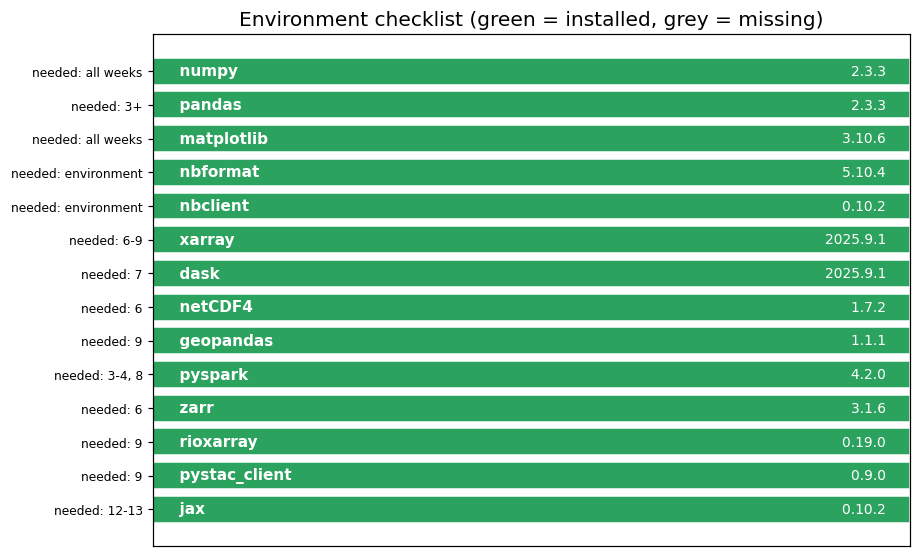

In [16]:

# The checklist as a figure -- green = installed, grey = missing. This figure is this week's 'deliverable'.
labels = [f"{mod}  ({wk})" for mod, use, wk, ok, ver in status]
oks    = [ok for *_, ok, _ in status]
colors = ["#2ca25f" if ok else "#bdbdbd" for ok in oks]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
y = np.arange(len(labels))
ax.barh(y, [1] * len(labels), color=colors, edgecolor="white")
for i, (mod, use, wk, ok, ver) in enumerate(status):
    txt = ver if ok else "missing -> install when needed"
    ax.text(0.02, i, f"  {mod}", va="center", ha="left", fontsize=10,
            weight="bold", color="white")
    ax.text(0.98, i, txt + "  ", va="center", ha="right", fontsize=9, color="white")
ax.set_yticks(y)
ax.set_yticklabels([f"needed: {wk}" for _, _, wk, _, _ in status], fontsize=8)
ax.set_xticks([]); ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_title("Environment checklist (green = installed, grey = missing)")
plt.tight_layout()


---
## 2. Reproducibility — pin the seed and pin the versions

Even with identical code, results diverge if (1) the **random seed** differs or (2)
the **library versions** differ. In a scientific pipeline that is fatal: if you cannot
reproduce yesterday's RMSE today, you cannot measure improvement.

Start with the seed. Give `np.random.default_rng(seed)` the **same seed** and two runs
agree byte for byte; give it a **different seed** and they diverge. Let us confirm that
with a random walk, both visually and numerically.


In [17]:

def walk(seed, n=300):
    r = np.random.default_rng(seed)
    return np.cumsum(r.normal(size=n))

a1 = walk(42)      # same seed
a2 = walk(42)      # same seed -> must be exactly identical
b  = walk(7)       # different seed -> diverges

same_diff = np.max(np.abs(a1 - a2))
diff_diff = np.max(np.abs(a1 - b))
print(f"same seed (42 vs 42), max abs diff : {same_diff:.3e}   (expected: exactly 0)")
print(f"diff seed (42 vs 7),  max abs diff : {diff_diff:.3f}")
assert same_diff == 0.0, "same seed but different result -> reproducibility is broken"
print("-> the same seed reproduces exactly, a different seed makes a different trajectory.")


same seed (42 vs 42), max abs diff : 0.000e+00   (expected: exactly 0)
diff seed (42 vs 7),  max abs diff : 35.985
-> the same seed reproduces exactly, a different seed makes a different trajectory.


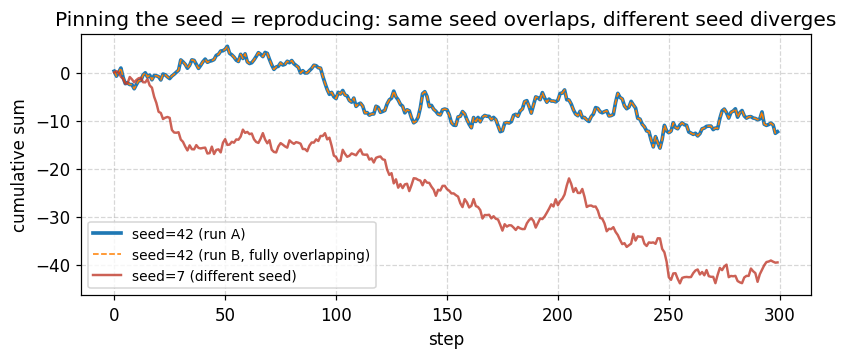

In [18]:

fig, ax = plt.subplots(figsize=(7.6, 3.4))
ax.plot(a1, lw=2.4, color="#1f78b4", label="seed=42 (run A)")
ax.plot(a2, lw=1.0, color="#ff7f00", ls="--", label="seed=42 (run B, fully overlapping)")
ax.plot(b,  lw=1.6, color="#c0392b", alpha=0.8, label="seed=7 (different seed)")
ax.set_xlabel("step"); ax.set_ylabel("cumulative sum")
ax.set_title("Pinning the seed = reproducing: same seed overlaps, different seed diverges")
ax.grid(True, ls="--", alpha=0.5); ax.legend(fontsize=9)
plt.tight_layout()


Version pinning is done with a `requirements.txt`. If you **extract with code** the
versions of the key packages in the current environment and save them to a file,
somebody else can rebuild the same environment with `pip install -r requirements.txt`.
(Below we write it into the working directory and only inspect its contents — the
course repository is left alone.)


In [19]:
status

[('numpy', 'numeric arrays', 'all weeks', True, '2.3.3'),
 ('pandas', 'tabular data', '3+', True, '2.3.3'),
 ('matplotlib', 'plotting', 'all weeks', True, '3.10.6'),
 ('nbformat', 'notebook build', 'environment', True, '5.10.4'),
 ('nbclient', 'notebook execution', 'environment', True, '0.10.2'),
 ('xarray', 'labelled ND arrays', '6-9', True, '2025.9.1'),
 ('dask', 'lazy/parallel ops', '7', True, '2025.9.1'),
 ('netCDF4', 'NetCDF I/O', '6', True, '1.7.2'),
 ('geopandas', 'vector geodata', '9', True, '1.1.1'),
 ('pyspark', 'distributed DataFrame', '3-4, 8', True, '4.2.0'),
 ('zarr', 'chunked storage', '6', True, '3.1.6'),
 ('rioxarray', 'raster data', '9', True, '0.19.0'),
 ('pystac_client', 'STAC catalogue', '9', True, '0.9.0'),
 ('jax', 'differentiable calc', '12-13', True, '0.10.2')]

In [20]:
# On *_: it's Python's "unpack the rest and throw it away" idiom.
# * is starred (extended) unpacking, which collects leftover items into a list; 
# _ is the conventional name for a value you don't intend to use. 
# Together they mean "I want these specific items, ignore everything else."
#
# first, *_ = [1, 2, 3, 4]        # first = 1,  _ = [2, 3, 4]
# *_, last = [1, 2, 3, 4]         # last = 4
# first, *_, last = [1, 2, 3, 4]  # first = 1, last = 4, _ = [2, 3]


# Record the versions of the installed key packages in requirements format.
pinned = []
for mod, *_ , ok, ver in status:
    if ok and ver not in ("?",) and not str(ver).startswith("import"):
        dist = "pystac-client" if mod == "pystac_client" else mod
        pinned.append(f"{dist}=={ver}")

req_path = os.path.join(WORK, "requirements.txt")
with open(req_path, "w") as f:
    f.write("\n".join(pinned) + "\n")

print("generated requirements.txt (only what is installed):\n")
print("\n".join(pinned))
print(f"\nhow to rebuild:  python -m venv .venv && .venv/bin/pip install -r requirements.txt")


generated requirements.txt (only what is installed):

numpy==2.3.3
pandas==2.3.3
matplotlib==3.10.6
nbformat==5.10.4
nbclient==0.10.2
xarray==2025.9.1
dask==2025.9.1
netCDF4==1.7.2
geopandas==1.1.1
pyspark==4.2.0
zarr==3.1.6
rioxarray==0.19.0
pystac-client==0.9.0
jax==0.10.2

how to rebuild:  python -m venv .venv && .venv/bin/pip install -r requirements.txt


> **Observe:** reproducibility has two axes — **pin the seed** to lock the randomness,
> **pin the versions** to lock how the code executes. Every Kaggle submission all stand on this principle: **pin code + data + environment together** and only then you can trust a result.

---
## 3. The shell and Unix pipes — the archetype of data processing

The mindset of distributed data processing (Spark, MapReduce) actually comes from the
old Unix shell philosophy: **chain small tools with a pipe (`|`) and let the stream
flow through them.** Each tool does one thing well (`grep` = filter, `sort` = sort,
`uniq -c` = aggregate) and passes the data through one line at a time. That is exactly
the archetype of **filter → map → reduce**.

For the exercise we generate a small **AWS weather observation CSV** inside the
notebook. Then we run genuine shell commands through `subprocess`.


In [21]:

# Synthetic AWS observations: 5 stations x many timestamps of (temperature, humidity).
stations = [108, 112, 133, 143, 159]     # station numbers in KMA ASOS/AWS style
base_temp = {108: 26.0, 112: 24.5, 133: 27.5, 143: 23.0, 159: 28.5}

rows = ["station,datetime,temp,humidity"]
records = []                              # reused later in the MapReduce section
robs = np.random.default_rng(1)
for h in range(24):                       # 24 hours of one day
    diurnal = 3.0 * np.sin(2 * np.pi * (h - 9) / 24)   # peak in the afternoon
    for s in stations:
        # Some stations report twice an hour -> different sample counts per station.
        reps = 2 if s in (108, 133) else 1
        for _ in range(reps):
            t = base_temp[s] + diurnal + float(robs.normal(0, 0.6))
            rh = float(np.clip(70 - 1.5 * (t - 24) + robs.normal(0, 3), 20, 100))
            rows.append(f"{s},2025-08-01T{h:02d}:00,{t:.2f},{rh:.1f}")
            records.append((s, round(t, 2)))

csv_path = os.path.join(WORK, "aws_sample.csv")
with open(csv_path, "w") as f:
    f.write("\n".join(rows) + "\n")

print(f"created: {csv_path}  ({len(rows)-1} observations plus 1 header line)")
print("first 6 lines:")
for line in rows[:6]:
    print("  ", line)


created: /var/folders/hh/w5xjnck119d_h0x6gxztgrwr0000gn/T/course410_wk02_1ub3df0c/aws_sample.csv  (168 observations plus 1 header line)
first 6 lines:
   station,datetime,temp,humidity
   108,2025-08-01T00:00,24.09,72.3
   108,2025-08-01T00:00,24.08,66.0
   112,2025-08-01T00:00,22.92,73.0
   133,2025-08-01T00:00,25.06,70.2
   133,2025-08-01T00:00,25.60,68.5


In [22]:

def sh(cmd):
    # Run a shell command in the working directory and return stdout (headless-safe).
    out = subprocess.run(cmd, shell=True, cwd=WORK,
                         capture_output=True, text=True)
    return out.stdout.rstrip("\n")

# (1) wc: total number of observations (header excluded)
n_lines = sh("wc -l < aws_sample.csv")
print(f"wc -l  ->  total lines in file = {n_lines}  (header included)")

# (2) grep: filter a single station (filter)
n_108 = sh("grep -c '^108,' aws_sample.csv")
print(f"grep '^108,' -c  ->  reports from station 108 = {n_108}")


wc -l  ->  total lines in file =      169  (header included)
grep '^108,' -c  ->  reports from station 108 = 48


In [23]:

# (3) A pipe: drop the header -> extract the station column -> sort -> count
#     tail -n +2 : skip the single header line
#     cut -d, -f1: keep only the first column (station)
#     sort | uniq -c: count per group (= GROUP BY station COUNT(*))
pipe = "tail -n +2 aws_sample.csv | cut -d, -f1 | sort | uniq -c"
print("shell pipeline:")
print("  ", pipe)
print("\nresult (count  station):")
print(sh(pipe))

# Cross-check the same aggregation in Python
py_counts = Counter(s for s, _ in records)
print("\nPython Counter cross-check:", dict(sorted(py_counts.items())))


shell pipeline:
   tail -n +2 aws_sample.csv | cut -d, -f1 | sort | uniq -c

result (count  station):
  48 108
  24 112
  48 133
  24 143
  24 159

Python Counter cross-check: {108: 48, 112: 24, 133: 48, 143: 24, 159: 24}


> **Observe:** a **single line** chaining three tools with pipes, `cut | sort | uniq
> -c`, has already performed a "count per station (GROUP BY)", and it matches the
> Python `Counter` result exactly. Each tool streams the data line by line and does
> only its own job. This **filter → sort/shuffle → aggregate** structure *is* the
> MapReduce we are about to see, and it is Spark's `groupBy`. Note too
> that only stations 108 and 133 report twice an hour, so their counts differ.

---
## 4. Git — putting experiments under version control

The last piece of reproducibility is **version control**. To reproduce "yesterday's
RMSE" you need yesterday's **code and configuration** still intact. Git stacks the
history of changes as snapshots (commits) and attaches a **hash** to each one. That
single hash is the proof that "this exact code produced this result".

Let us create a small experiment repository in the working directory, stack a few
commits and branch off. (All inside the temporary directory — nothing to do with the
course repository.)


In [24]:

REPO = os.path.join(WORK, "experiment")
os.makedirs(REPO, exist_ok=True)

HAS_GIT = shutil.which("git") is not None

# Pin author/committer dates and identity so the commits are deterministic.
GENV = os.environ.copy()
GENV["GIT_AUTHOR_DATE"] = "2026-03-04T09:00:00+09:00"
GENV["GIT_COMMITTER_DATE"] = "2026-03-04T09:00:00+09:00"
GBASE = ["git", "-c", "user.name=Course410", "-c", "user.email=course410@example.com",
         "-c", "init.defaultBranch=main", "-c", "commit.gpgsign=false"]

def git(*args):
    return subprocess.run(GBASE + list(args), cwd=REPO, env=GENV,
                          capture_output=True, text=True)

def write(fname, text):
    with open(os.path.join(REPO, fname), "w") as f:
        f.write(text)

commits = []   # (short_hash, subject) -- replaced by synthetic values if git is absent
if HAS_GIT:
    git("init", "-q")
    # c1: baseline persistence experiment
    write("analyze.py", "kappa = 0.0  # open-loop baseline\nlead = 6\n")
    write("requirements.txt", "numpy\npandas\n")
    git("add", "-A"); git("commit", "-q", "-m", "baseline: persistence, kappa=0")
    # c2: add the observation update (nudging)
    write("analyze.py", "kappa = 0.5  # add nudging\nlead = 6\n")
    git("add", "-A"); git("commit", "-q", "-m", "add closed-loop nudging kappa=0.5")
    # branch: try stronger nudging
    git("checkout", "-q", "-b", "exp/higher-kappa")
    write("analyze.py", "kappa = 0.8  # stronger nudging\nlead = 6\n")
    git("add", "-A"); git("commit", "-q", "-m", "experiment: kappa=0.8")
    # back to main and continue
    git("checkout", "-q", "main")
    write("analyze.py", "kappa = 0.5\nlead = 6\nsensors = 50  # tune sensor count\n")
    git("add", "-A"); git("commit", "-q", "-m", "tune: sensors=50")

    log = git("log", "--all", "--pretty=%h|%s").stdout.strip().splitlines()
    for line in log:
        h, s = line.split("|", 1)
        commits.append((h, s))
    print("git log --all:")
    print(git("log", "--oneline", "--graph", "--all").stdout)
else:
    commits = [("d4e5f6a", "tune: sensors=50"), ("c3d4e5b", "experiment: kappa=0.8"),
               ("b2c3d4e", "add closed-loop nudging kappa=0.5"),
               ("a1b2c3d", "baseline: persistence, kappa=0")]
    print("git not installed -- demonstrating the concept with a synthetic log.")

print("number of commits:", len(commits))


git log --all:
* 313e6e5 experiment: kappa=0.8
| * a067687 tune: sensors=50
|/  
* 8d31de8 add closed-loop nudging kappa=0.5
* b8ce97b baseline: persistence, kappa=0

number of commits: 4


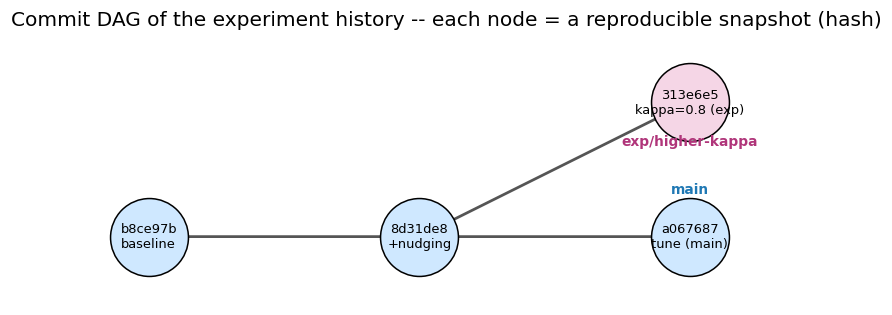

In [25]:

# Draw the commit history as a DAG: 3 commits on main + 1 on the exp branch.
# The topology is exactly the one we created (identical whether real or synthetic).
sub2hash = {s: h for h, s in commits}
def H(sub):
    return sub2hash.get(sub, "-------")[:7]

nodes = {
    "c1": (0, 0, f'{H("baseline: persistence, kappa=0")}\nbaseline'),
    "c2": (1, 0, f'{H("add closed-loop nudging kappa=0.5")}\n+nudging'),
    "c3": (2, 0, f'{H("tune: sensors=50")}\ntune (main)'),
    "b1": (2, 1, f'{H("experiment: kappa=0.8")}\nkappa=0.8 (exp)'),
}
edges = [("c1", "c2"), ("c2", "c3"), ("c2", "b1")]

fig, ax = plt.subplots(figsize=(8.2, 3.0))
for a, b in edges:
    x0, y0, _ = nodes[a]; x1, y1, _ = nodes[b]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#555"))
for key, (x, y, label) in nodes.items():
    c = "#f5d6e6" if key == "b1" else "#cfe8ff"
    ax.scatter([x], [y], s=2600, color=c, edgecolors="black", zorder=3)
    ax.text(x, y, label, ha="center", va="center", fontsize=8.5, zorder=4)
ax.text(2, 0.32, "main", fontsize=9, color="#1f78b4", ha="center", weight="bold")
ax.text(2, 0.68, "exp/higher-kappa", fontsize=9, color="#b0357a", ha="center", weight="bold")
ax.set_xlim(-0.5, 2.7); ax.set_ylim(-0.5, 1.5); ax.axis("off")
ax.set_title("Commit DAG of the experiment history -- each node = a reproducible snapshot (hash)")
plt.tight_layout()


> **Observe:** each commit hash is the fingerprint that locks in "this code + this
> configuration produced this result". A branch (`exp/higher-kappa`) lets you try an
> alternative (κ=0.8) **without wrecking the mainline** — merge it if it is good,
> throw it away if it is not. Manage Kaggle submissions the same way: write the commit
> hash next to the submission score and you can always go back to the code that
> produced it. **Reproducibility = the tripod of code (Git) + data + environment
> (requirements).**

---
## 5. Why distributed and parallel processing — the limits of one machine

At the end of last week we saw that a realistic city twin can reach hundreds of GB.
Processing that on a single computer runs into two walls:

1. **The memory wall** — if the data is larger than RAM you cannot load it at all.
2. **The time wall** — the throughput of one core is finite. As the data grows the
   processing time grows linearly, and at some point you enter the "cannot finish
   within a day" regime.

Let us draw those walls with a simple model: one node reads and processes $B$ GB per
second and has $M$ GB of RAM.


In [26]:

GB = 1
throughput = 0.5     # per-node throughput (GB/s), a rough assumption
RAM = 16.0           # RAM of a single node (GB)
DAY = 86400          # one day in seconds

# Data volumes of last week's scenarios (reused): (nx, ny, nvar, nt) float32
scen = {
    "Today's lab (50^2, 200 steps)":                (50, 50, 1, 200),
    "City 1km grid (1000^2, 1 var, 1 yr hourly)":   (1000, 1000, 1, 24 * 365),
    "Multivar city twin (2000^2, 8 vars, 1 yr)":    (2000, 2000, 8, 24 * 365),
}
sizes_gb = {}
print(f"{'Scenario':<44}{'Size(GB)':>11}{'Time':>13}{'Over RAM?':>11}")
print("-" * 79)
for name, (nx, ny, nv, nt) in scen.items():
    gb = nx * ny * nv * nt * 4 / 1024**3
    sizes_gb[name] = gb
    secs = gb / throughput
    hrs = secs / 3600
    over = "yes" if gb > RAM else "no"
    print(f"{name:<44}{gb:>11.2f}{hrs:>12.1f}h{over:>11}")


Scenario                                       Size(GB)         Time  Over RAM?
-------------------------------------------------------------------------------
Today's lab (50^2, 200 steps)                      0.00         0.0h         no
City 1km grid (1000^2, 1 var, 1 yr hourly)        32.63         0.0h        yes
Multivar city twin (2000^2, 8 vars, 1 yr)       1044.27         0.6h        yes


multivariate city twin: 1044.3 GB > RAM 16 GB (memory wall), single-node processing 0.6h.
Split over N nodes and in theory the time drops to ~ 0.6h / N, and the memory to 1/N.


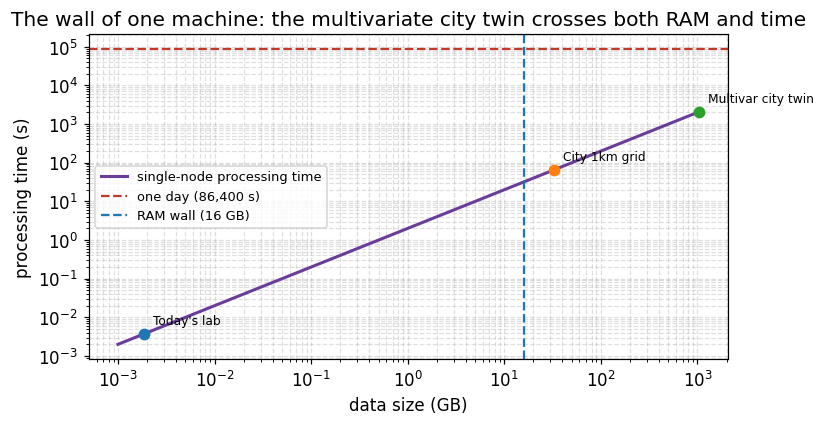

In [15]:

# Data size -> single-node processing time. The RAM wall and the 'one day' wall are marked.
g = np.logspace(-3, 3, 200)           # 0.001 ~ 1000 GB
t = g / throughput                    # seconds

fig, ax = plt.subplots(figsize=(7.6, 4.0))
ax.loglog(g, t, lw=2, color="#6a3d9a", label="single-node processing time")
ax.axhline(DAY, ls="--", color="#c0392b", label="one day (86,400 s)")
ax.axvline(RAM, ls="--", color="#1f78b4", label=f"RAM wall ({RAM:.0f} GB)")
for name, gb in sizes_gb.items():
    ax.scatter([gb], [gb / throughput], s=45, zorder=5)
    ax.annotate(name.split(" (")[0], (gb, gb / throughput),
                textcoords="offset points", xytext=(6, 6), fontsize=8)
ax.set_xlabel("data size (GB)"); ax.set_ylabel("processing time (s)")
ax.set_title("The wall of one machine: the multivariate city twin crosses both RAM and time")
ax.grid(True, which="both", ls="--", alpha=0.4); ax.legend(fontsize=8.5)
plt.tight_layout()

big = sizes_gb["Multivar city twin (2000^2, 8 vars, 1 yr)"]
print(f"multivariate city twin: {big:.1f} GB > RAM {RAM:.0f} GB (memory wall), "
      f"single-node processing {big/throughput/3600:.1f}h.")
print(f"Split over N nodes and in theory the time drops to ~ {big/throughput/3600:.1f}h / N, and the memory to 1/N.")


> **Observe:** the multivariate city twin crosses the RAM wall (16 GB) and the
> 'one day' time wall **at the same time**. There is only one remedy — **split the
> work across several nodes.** Chop the data up and spread it over many machines and
> both memory and time drop roughly by $1/N$. But putting the data on many machines
> creates a new problem: **how do we split the storage (Section 6, HDFS) and how do we
> split the computation (Section 7, MapReduce)?**

---
## 6. The HDFS idea — block splitting and replication (fault tolerance)

The classic solution for spreading data across many nodes is **HDFS** (Hadoop
Distributed File System). There are two core ideas:

| Idea | What it means | Why |
|---|---|---|
| **Block splitting** | Chop a big file into fixed-size **blocks** (128 MB by default) | distributed storage and parallel processing across nodes |
| **Replication** | Store each block on several nodes, **$r$ replicas** (3 by default) | data survives a node failure (fault tolerance) |

Let us **simulate** placing blocks on nodes and see whether the data survives when
nodes fail. The claim is this: **with $r$ replicas, no block is ever lost as long as at
most ($r-1$) nodes fail simultaneously** 


In [27]:

N_NODES = 8          # number of data nodes
N_BLOCKS = 20        # number of blocks the file is split into
R = 3                # replication factor
rp = np.random.default_rng(2)

# Place each block on R distinct nodes -> placement[block] = set of nodes
placement = [set(rp.choice(N_NODES, size=R, replace=False)) for _ in range(N_BLOCKS)]

# Placement matrix (blocks x nodes): 1 means a replica lives there
M = np.zeros((N_BLOCKS, N_NODES), dtype=int)
for b, nodes in enumerate(placement):
    for nd in nodes:
        M[b, nd] = 1

print(f"{N_BLOCKS} blocks, {N_NODES} nodes, replication R={R}")
print(f"total replicas = {M.sum()}  (= blocks x R = {N_BLOCKS*R})")
print(f"average blocks per node = {M.sum()/N_NODES:.1f}")


20 blocks, 8 nodes, replication R=3
total replicas = 60  (= blocks x R = 60)
average blocks per node = 7.5


In [28]:

def lost_blocks(failed_nodes):
    # A block is lost only when all R of its replicas sit on failed nodes.
    failed = set(failed_nodes)
    return sum(1 for nodes in placement if nodes <= failed)

# Number of blocks lost when k = 0..N_NODES nodes fail at random (walking towards the worst case).
rf = np.random.default_rng(3)
ks = list(range(0, N_NODES + 1))
lost_curve = []
for k in ks:
    trials = [lost_blocks(rf.choice(N_NODES, size=k, replace=False)) for _ in range(200)]
    lost_curve.append(np.mean(trials))

# Theory: if k < R, no block can have all R replicas dead -> zero loss.
for k in range(R):
    worst = max(lost_blocks(rf.choice(N_NODES, size=k, replace=False)) for _ in range(500))
    assert worst == 0, f"k={k}(<R) yet a block was lost -- the replication invariant is violated"
print(f"verified: k=0..{R-1} simultaneous node failures -> always 0 blocks lost (the guarantee of R={R} replication).")
print(f"mean blocks lost: " + ", ".join(f"k={k}:{v:.1f}" for k, v in zip(ks, lost_curve)))


verified: k=0..2 simultaneous node failures -> always 0 blocks lost (the guarantee of R=3 replication).
mean blocks lost: k=0:0.0, k=1:0.0, k=2:0.0, k=3:0.4, k=4:1.2, k=5:3.6, k=6:7.1, k=7:12.2, k=8:20.0


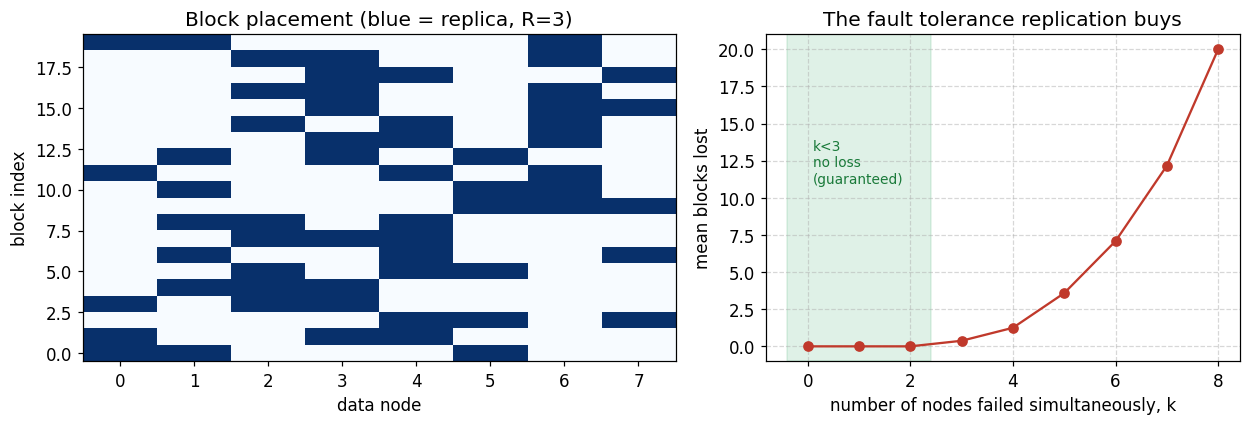

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0),
                         gridspec_kw={"width_ratios": [1.25, 1]})

# (left) blocks x nodes placement heatmap
ax = axes[0]
ax.imshow(M, aspect="auto", cmap="Blues", origin="lower")
ax.set_xlabel("data node"); ax.set_ylabel("block index")
ax.set_xticks(range(N_NODES))
ax.set_title(f"Block placement (blue = replica, R={R})")

# (right) number of simultaneously failed nodes k vs mean blocks lost
ax = axes[1]
ax.plot(ks, lost_curve, "o-", color="#c0392b")
ax.axvspan(-0.4, R - 1 + 0.4, color="#2ca25f", alpha=0.15)
ax.text(0.1, N_BLOCKS * 0.55, f"k<{R}\nno loss\n(guaranteed)", color="#1a7a3a", fontsize=9)
ax.set_xlabel("number of nodes failed simultaneously, k"); ax.set_ylabel("mean blocks lost")
ax.set_title("The fault tolerance replication buys")
ax.grid(True, ls="--", alpha=0.5)
plt.tight_layout()


> **Observe:** with replication factor $R=3$, the simulation verified that as long as
> at most $k \le 2\,(=R-1)$ nodes fail simultaneously, **exactly 0** blocks are lost
> (the green band). Only once $k$ reaches $R$ does loss become possible at all. This is
> how HDFS keeps data safe on top of hundreds of cheap machines — **split the storage,
> but protect it with redundancy.** Now that storage is split, it is the computation's
> turn.

---
## 7. MapReduce — distributed aggregation (map → shuffle → reduce)

If the data is already split into blocks across several nodes, it pays to do the
computation **where the data is** (moving code is cheaper than moving data).
**MapReduce** formalises that idea in three stages:

1. **Map** — each partition (block) independently emits `(key, value)` pairs. Parallel.
2. **Shuffle** — gather values that share a key.
3. **Reduce** — combine the values per key into the final result.

The shell's `sort | uniq -c` in Section 3 had exactly this structure. This time,
instead of counts, we compute the **mean temperature per station** in a distributed
way. There is one trap: **means cannot simply be combined** (the mean of means ≠ the
overall mean when the sample sizes differ). So what reduce moves around is not a mean
but a **(sum, count)** partial aggregate.


In [29]:

# records = [(station, temp), ...]  (created in Section 3)
def partition(recs, P):
    # Round-robin distribution into P partitions (= blocks).
    parts = [[] for _ in range(P)]
    for i, r in enumerate(recs):
        parts[i % P].append(r)
    return parts

def map_phase(part):
    # Each record -> (station, (temp, 1)).  count=1 is emitted for the partial aggregate.
    return [(s, (t, 1)) for (s, t) in part]

def shuffle(mapped):
    # Gather the values that share a key (station).
    groups = {}
    for lst in mapped:
        for k, v in lst:
            groups.setdefault(k, []).append(v)
    return groups

def reduce_phase(groups):
    # Accumulate (sum, count) per key -> mean.
    out = {}
    for k, vals in groups.items():
        tot = sum(t for t, _ in vals)
        cnt = sum(c for _, c in vals)
        out[k] = tot / cnt
    return out

def mapreduce_mean(recs, P):
    parts = partition(recs, P)                 # distributed storage (blocks)
    mapped = [map_phase(p) for p in parts]      # Map (parallel per node)
    groups = shuffle(mapped)                     # Shuffle
    return reduce_phase(groups)                  # Reduce

# The serial ground truth (everything at once)
serial = {}
for s in stations:
    ts = [t for (st, t) in records if st == s]
    serial[s] = sum(ts) / len(ts)

print(f"{'Station':>8}{'Serial mean':>14}{'MapReduce(P=4)':>16}")
print("-" * 38)
mr4 = mapreduce_mean(records, P=4)
for s in stations:
    print(f"{s:>8}{serial[s]:>14.3f}{mr4[s]:>16.3f}")


 Station   Serial mean  MapReduce(P=4)
--------------------------------------
     108        25.938          25.938
     112        24.386          24.386
     133        27.359          27.359
     143        22.952          22.952
     159        28.400          28.400


In [30]:

# The key check: changing the number of partitions (blocks) must not change the result at all.
print("maximum error against the serial answer, as a function of the partition count P:")
for P in [1, 2, 3, 5, 8, 13]:
    mr = mapreduce_mean(records, P)
    max_err = max(abs(mr[s] - serial[s]) for s in stations)
    print(f"  P={P:>2}  max abs error = {max_err:.2e}")
    assert max_err < 1e-12, "the number of partitions must not change the result"
print("-> identical to the serial answer regardless of P (the correctness of distributed aggregation).")

# For contrast: why 'just averaging the averages' is wrong (why partial aggregates are needed).
parts = partition(records, 4)
naive = {}
for p in parts:
    for s in stations:
        ts = [t for (st, t) in p if st == s]
        if ts:
            naive.setdefault(s, []).append(sum(ts) / len(ts))
naive_mean = {s: sum(v) / len(v) for s, v in naive.items()}
wrong = max(abs(naive_mean[s] - serial[s]) for s in stations)
print(f"\n(contrast) averaging the per-partition means -> max error {wrong:.3f}  "
      f"(sample sizes differ, so the 'mean of means' is wrong -> reduce must carry (sum, count))")


maximum error against the serial answer, as a function of the partition count P:
  P= 1  max abs error = 0.00e+00
  P= 2  max abs error = 1.07e-14
  P= 3  max abs error = 1.07e-14
  P= 5  max abs error = 1.07e-14
  P= 8  max abs error = 7.11e-15
  P=13  max abs error = 1.07e-14
-> identical to the serial answer regardless of P (the correctness of distributed aggregation).

(contrast) averaging the per-partition means -> max error 0.000  (sample sizes differ, so the 'mean of means' is wrong -> reduce must carry (sum, count))


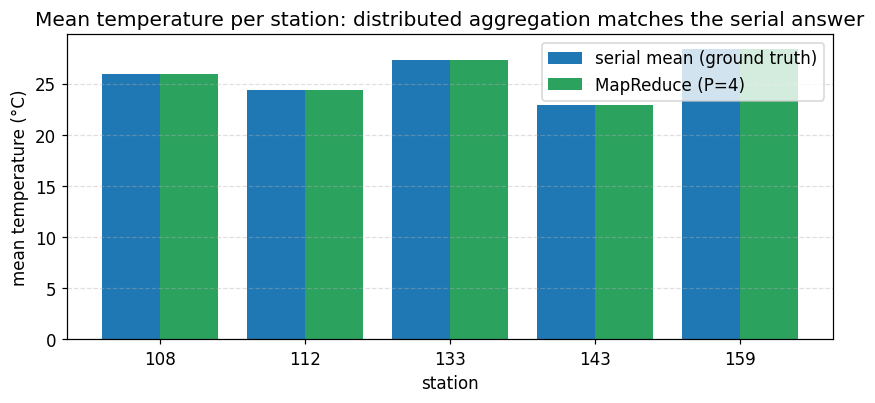

In [31]:

fig, ax = plt.subplots(figsize=(7.8, 3.8))
x = np.arange(len(stations))
sv = [serial[s] for s in stations]
mv = [mr4[s] for s in stations]
ax.bar(x - 0.2, sv, width=0.4, color="#1f78b4", label="serial mean (ground truth)")
ax.bar(x + 0.2, mv, width=0.4, color="#2ca25f", label="MapReduce (P=4)")
ax.set_xticks(x); ax.set_xticklabels(stations)
ax.set_xlabel("station"); ax.set_ylabel("mean temperature (°C)")
ax.set_title("Mean temperature per station: distributed aggregation matches the serial answer")
ax.grid(True, ls="--", alpha=0.4, axis="y"); ax.legend()
plt.tight_layout()


> **Observe:** whether we use 1 partition (block) or chop it into 13, the **maximum
> error is effectively 0** ($<10^{-12}$) — MapReduce splits the computation and still
> produces the same answer as the serial version. The decisive point is that what
> reduce moves around is not a 'mean' but a **(sum, count)** partial aggregate: simply
> averaging the per-partition means is wrong because the sample sizes differ. Spark in
> Weeks 3–4 does exactly this `groupBy().agg()` automatically on a real cluster — today
> we built its internals by hand.

---
## 8. The distributed stack and what comes next — plus your Kaggle account

The pieces we just built by hand — block splitting and replication (HDFS), and
map/shuffle/reduce — are what the distributed stack from **Hadoop to Spark** runs at
real scale.

| Layer | Tool | In this course |
|---|---|---|
| distributed storage | HDFS / object storage | **concept only** (Section 6 today) |
| distributed execution | MapReduce → **Spark** | labs in Weeks 3–4 (extending Section 7 today) |
| scientific data | NetCDF, Zarr + Xarray/Dask | Weeks 6–7 |
| parallel simulation | OpenMP, MPI, JAX | Weeks 10–12 |

Spark is faster than MapReduce because it is **memory-based with lazy execution**, and
its `DataFrame` and `SQL` express today's `groupBy` aggregation concisely. From next
week we aggregate real observations on top of it.


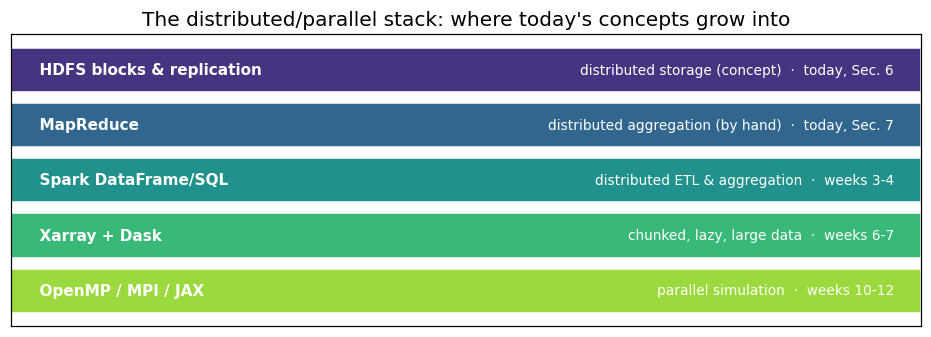

In [32]:

# Today's concepts -> the weeks that scale them up, at a glance.
stack = [
    ("HDFS blocks & replication", "distributed storage (concept)", "today, Sec. 6"),
    ("MapReduce",                 "distributed aggregation (by hand)", "today, Sec. 7"),
    ("Spark DataFrame/SQL",       "distributed ETL & aggregation", "weeks 3-4"),
    ("Xarray + Dask",             "chunked, lazy, large data",   "weeks 6-7"),
    ("OpenMP / MPI / JAX",        "parallel simulation",         "weeks 10-12"),
]
fig, ax = plt.subplots(figsize=(8.6, 3.2))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(stack)))
for i, ((name, role, wk), c) in enumerate(zip(stack, colors)):
    ax.barh(i, 1, color=c, edgecolor="white")
    ax.text(0.02, i, f"  {name}", va="center", ha="left", fontsize=10,
            weight="bold", color="white")
    ax.text(0.98, i, f"{role}  ·  {wk}  ", va="center", ha="right",
            fontsize=9, color="white")
ax.set_yticks([]); ax.set_xticks([]); ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.set_title("The distributed/parallel stack: where today's concepts grow into")
plt.tight_layout()


<!-- ### Kaggle to-do this week — create your account

The competition opens in Week 3, but create the account ahead of time.

1. Sign up at [kaggle.com](https://www.kaggle.com) (school e-mail recommended) and set
   your profile/username.
2. Join the Community Competition through the **invitation link** handed out in class
   (it is not searchable).
3. Issue an **API token (kaggle.json)** under `Settings → Account` so you are ready to
   automate submissions.
4. Check the team naming rules, if any.

> Creating the account and calling the API need network access and credentials, so this
> notebook does not run them (the build-environment isolation principle). Instead we
> check the **format of a local submission file** below — format errors are the single
> most common mistake in the first Week 3 submission. -->


<!-- 
# Submission format self-check: mimic the sample_submission shape (e.g. id,temp) and validate only.
import io, csv as _csv

sample = "id,temp\n0,25.1\n1,24.8\n2,26.3\n"
def validate_submission(text, id_col="id", target="temp"):
    reader = list(_csv.reader(io.StringIO(text)))
    header, data = reader[0], reader[1:]
    problems = []
    if header != [id_col, target]:
        problems.append(f"header is not [{id_col},{target}]: {header}")
    ids = [row[0] for row in data]
    if len(ids) != len(set(ids)):
        problems.append("duplicate ids present")
    for i, row in enumerate(data):
        try:
            float(row[1])
        except ValueError:
            problems.append(f"row {i}: prediction is not a number: {row[1]!r}")
    return problems

probs = validate_submission(sample)
print("sample submission check:", "passed ✅" if not probs else probs)
bad = "id,temp\n0,25.1\n0,x\n"          # duplicate id + non-numeric
print("broken submission check:", validate_submission(bad)) -->


---
## 🔬 Exercises

The problems below extend the pieces we built today, one step at a time. A working
reference solution follows each one, so try it yourself first and then compare.


**Exercise 1.** Extend the shell pipeline so that instead of counting reports per
station it counts the most frequent **hour** in the file (the hour part of the
`datetime` column). Cross-check with Python's `Counter`.


In [24]:

# Cut the 'THH' part out of the datetime column (field 2) and count per hour.
pipe = ("tail -n +2 aws_sample.csv | cut -d, -f2 | cut -dT -f2 | cut -d: -f1 "
        "| sort | uniq -c | sort -rn | head -3")
print("top-3 most frequent hours (count  hour):")
print(sh(pipe))

hours = [line.split("T")[1][:2] for line in rows[1:]]
print("\nPython cross-check, top-3:", Counter(hours).most_common(3))
print("-> the same number of stations reports every hour, so the hourly counts are uniform (all tied).")


top-3 most frequent hours (count  hour):
   7 23
   7 22
   7 21

Python cross-check, top-3: [('00', 7), ('01', 7), ('02', 7)]
-> the same number of stations reports every hour, so the hourly counts are uniform (all tied).


**Exercise 2.** Vary the replication factor $R$ over 1, 2, 3, 4 and check how "the
number of simultaneously failed nodes $k$ at which data loss first appears" changes.
Does it match the theoretical value ($k=R$)?


In [25]:

rr = np.random.default_rng(5)
def first_loss_k(R, n_nodes=8, n_blocks=20, trials=300):
    place = [set(rr.choice(n_nodes, size=R, replace=False)) for _ in range(n_blocks)]
    for k in range(0, n_nodes + 1):
        worst = 0
        for _ in range(trials):
            failed = set(rr.choice(n_nodes, size=k, replace=False))
            worst = max(worst, sum(1 for nd in place if nd <= failed))
        if worst > 0:
            return k
    return None

for R in [1, 2, 3, 4]:
    k0 = first_loss_k(R)
    print(f"R={R}: loss first observed at k = {k0}  (theory: k=R={R})")
print("-> with R replicas, R nodes must die simultaneously before loss becomes possible (k=R).")


R=1: loss first observed at k = 1  (theory: k=R=1)
R=2: loss first observed at k = 2  (theory: k=R=2)
R=3: loss first observed at k = 3  (theory: k=R=3)
R=4: loss first observed at k = 4  (theory: k=R=4)
-> with R replicas, R nodes must die simultaneously before loss becomes possible (k=R).


**Exercise 3.** Extend MapReduce so that it computes the **mean, minimum and maximum**
per station in one pass instead of just the mean. What partial aggregate does reduce
have to carry? Verify that it matches the serial result.


In [26]:

# The partial aggregate = (sum, count, min, max). All four are associative, so they merge across partitions.
def mr_stats(recs, P):
    parts = partition(recs, P)
    groups = {}
    for p in parts:                        # map + local combine
        local = {}
        for s, t in p:
            if s not in local:
                local[s] = [t, 1, t, t]     # sum, cnt, min, max
            else:
                a = local[s]
                a[0] += t; a[1] += 1
                a[2] = min(a[2], t); a[3] = max(a[3], t)
        for s, a in local.items():
            groups.setdefault(s, []).append(a)
    out = {}
    for s, parts_agg in groups.items():     # reduce (merging the partial aggregates)
        S = sum(a[0] for a in parts_agg)
        C = sum(a[1] for a in parts_agg)
        mn = min(a[2] for a in parts_agg)
        mx = max(a[3] for a in parts_agg)
        out[s] = (S / C, mn, mx)
    return out

st = mr_stats(records, P=6)
print(f"{'Station':>8}{'mean':>9}{'min':>9}{'max':>9}")
print("-" * 35)
ok = True
for s in stations:
    ts = [t for (x, t) in records if x == s]
    ref = (sum(ts) / len(ts), min(ts), max(ts))
    ok &= max(abs(a - b) for a, b in zip(st[s], ref)) < 1e-12
    print(f"{s:>8}{st[s][0]:>9.3f}{st[s][1]:>9.2f}{st[s][2]:>9.2f}")
print("matches the serial answer:", ok)


 Station     mean      min      max
-----------------------------------
     108   25.938    22.35    29.56
     112   24.386    21.38    28.49
     133   27.359    24.01    31.19
     143   22.952    18.78    26.18
     159   28.400    24.61    31.31
matches the serial answer: True


**Exercise 4.** Write a function that summarises today's environment check as a
**"readiness score"**: if everything required for all weeks (numpy, pandas,
matplotlib) is present that is a minimal pass, and report the installation rate of the
rest as a percentage. Print which package is needed before which week alongside it.


In [27]:

core = {"numpy", "pandas", "matplotlib", "nbformat", "nbclient"}
installed = {mod for mod, *_ , ok, _ in status if ok}
missing = [(mod, wk) for mod, use, wk, ok, ver in status if not ok]

core_ready = core <= installed
pct = 100 * len(installed) / len(status)
print(f"core stack ready: {'✅ pass' if core_ready else '❌ incomplete'}  (core={sorted(core)})")
print(f"overall installation rate: {pct:.0f}%  ({len(installed)}/{len(status)})")
if missing:
    print("\nnot needed yet (install before the relevant week):")
    for mod, wk in missing:
        print(f"  - {mod:<15} -> install before week {wk}")
else:
    print("all packages installed.")


core stack ready: ✅ pass  (core=['matplotlib', 'nbclient', 'nbformat', 'numpy', 'pandas'])
overall installation rate: 100%  (14/14)
all packages installed.


---
## Summary

Today we laid the **foundation** for running the closed-loop twin reproducibly, week
after week:

- We **inspected the environment with code** — Python, CPU and the per-week packages —
  and produced this week's deliverable, the **environment checklist**. "Do not trust
  your eyes; confirm with code."
- **Reproducibility = seed + version pinning.** We confirmed that the maximum absolute
  difference for the same seed is exactly 0, and recorded the installed versions in a
  `requirements.txt`.
- We saw that **shell pipes** (`cut|sort|uniq -c`) and **Git** (commits, branches,
  hashes) are the archetypes of data processing and experiment reproduction
  respectively. Reproducibility is the **tripod of code + data + environment**.
- **Why distributed:** the multivariate city twin crosses both the RAM and the time
  wall → it has to be split.
- **HDFS:** block splitting + replication. We verified by simulation that $R$
  replicas mean **zero loss** up to $R-1$ simultaneous node failures.
- **MapReduce:** we computed the mean temperature per station with map→shuffle→reduce
  and confirmed it matches the serial answer ($<10^{-12}$) regardless of the partition
  count. Reduce carries the **(sum, count)** partial aggregate, not the mean.

> **Where are we in the pipeline?** Today we put down the basic distributed-processing
> concepts underpinning stage **② space-time alignment and aggregation**, plus the
> **reproducible environment** on which every stage stands. Next week (Week 3) Spark
> rewrites the MapReduce aggregation we built by hand today as `DataFrame` and `SQL` on
> a real distributed engine — **and the competition opens then too.**

### Further Exercises

1. Build a fresh venv from the `requirements.txt` and check that this notebook still
   runs unchanged.
2. In the HDFS simulation, if blocks are spread **evenly over the nodes rather than at
   random** (imitating rack awareness), does the risk of loss drop for the same $R$?
3. Add **variance** to the MapReduce `mr_stats` — which partial aggregates
   ($\sum x$, $\sum x^2$, $n$) are associative?
4. Approximate the **mean temperature per station** with the shell (use `awk`). Compare
   it with the Python result from Section 7.
5. Draw how the DAG changes if you merge the `exp/higher-kappa` branch into `main`.
